# What did the ERP actually send?

**Week 1, Wednesday. Round 1 of 3: the profile.** By the end of this notebook you can read a CSV
and a JSON feed, profile every field for presence, convertibility and distinct values, and
convert amounts on purpose, with every failure counted and logged rather than hidden.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "Before you total anything, tell me how many records you received, how
> many are complete, how many convert and how many are distinct. A total from a file you have
> not profiled is a guess with a comma in it."

Tuesday found that Retail-Plus orders per customer fell from 2.32 to 1.18, down 49 percent, and
that finding reached the leadership group. It was measured on the export exactly as the ERP
delivered it, with nothing checked, and this round starts where every reconciliation starts:
with what arrived.

**Setup.** The cell below finds the shared helper, `kit`, and defines the two functions the whole
day uses: `read_orders()`, which reads an export into dictionaries and remembers the file line
each row came from, and `convert()`, which turns an amount into rupees or says why it could not.
Nothing here prints a record.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

print("helper loaded; data folder:", DATA.name)

helper loaded; data folder: data


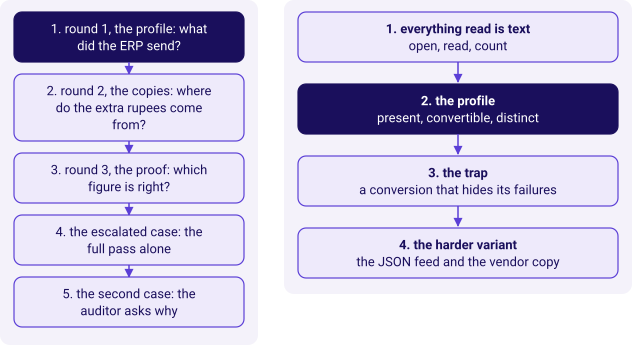

In [2]:
kit.side_by_side(
    kit.ladder(["round 1, the profile: what did the ERP send?", "round 2, the copies: where do the extra rupees come from?",
            "round 3, the proof: which figure is right?", "the escalated case: the full pass alone",
            "the second case: the auditor asks why"], lit=0, show=False),
    kit.vflow(["1. everything read is text\nopen, read, count",
               "2. the profile\npresent, convertible, distinct",
               "3. the trap\na conversion that hides its failures",
               "4. the harder variant\nthe JSON feed and the vendor copy"], lit=1, show=False),
)

## 1. Everything read from a file is text

The ERP sent an orders CSV. Before any total, open it and count what arrived, and look at what
Python holds for one amount. Opening the wrong name is the first thing that goes wrong on a
Wednesday, and it costs two minutes: read the last line, check the folder, move on.

**Predict before you run.** After `csv.DictReader` reads the file, what is the type of an
amount such as the first order's? a) `int`, since the column holds numbers; b) `float`, since
rupees can carry paise; c) `str`, since a CSV holds only text; d) it depends on the row.

In [3]:
with kit.expect_error() as err:
    open("orders.csv")            # the name a hurried analyst types from memory

raw = read_orders()
first = raw[0]
print(len(raw), "rows read")
print({k: first[k] for k in ("order_id", "segment", "quarter", "amount")})
print("the amount is held as", type(first["amount"]).__name__, repr(first["amount"]))

201 rows read
{'order_id': 'KR-02001', 'segment': 'Retail-Core', 'quarter': 'Q1', 'amount': '2200'}
the amount is held as str '2200'


**What happened.** The answer is c. The first call stops with `FileNotFoundError`, and its last
line names the file Python looked for in the notebook's own folder; the exports live in
`../data/`, which `read_orders()` already knows. The file then reads as 201 rows, and the first
amount is the text `'2200'`, not the number 2200. Every value a CSV gives back is text until
you convert it on purpose, so every sum, comparison and sort on an amount depends on a
conversion somebody chose.

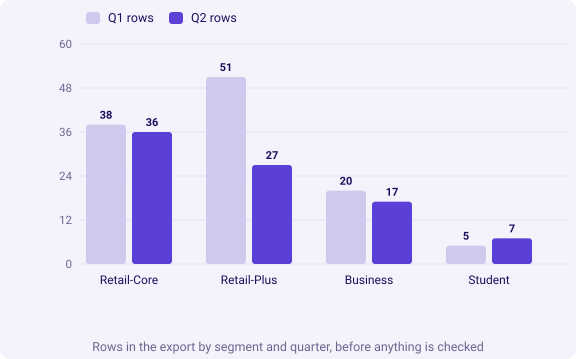

In [4]:
segments = ["Retail-Core", "Retail-Plus", "Business", "Student"]
rows_by = {q: [sum(1 for r in raw if r["quarter"] == q and r["segment"] == s) for s in segments]
           for q in ("Q1", "Q2")}
kit.columns(segments, [("Q1 rows", rows_by["Q1"]), ("Q2 rows", rows_by["Q2"])],
            title="Rows in the export by segment and quarter, before anything is checked")
kit.check("the export holds 201 rows", len(raw) == 201, f"{len(raw)}")
kit.check("every value arrives as text", all(isinstance(v, str) for r in raw for k, v in r.items() if k != "line"))
kit.check("the wrong name raised FileNotFoundError", err.name == "FileNotFoundError", err.name)

## 2. The profile: present, convertible, distinct

A profile asks three questions of every field before any analysis: is a value present, does it
convert to the type the field needs, and how many distinct values does it hold. The three
counts say what each field can be trusted for. An `order_id` that is present on every row but
distinct on fewer rows says something about the export; an amount present everywhere but
convertible on fewer says something about the total.

**Predict before you run.** Which field do you expect to show the biggest gap between
present and the 201 rows? a) `amount`, because money fields are messy; b) `discount`, which
Tuesday met as an optional field; c) `order_id`, because every export has gaps in its keys;
d) none, because an ERP export is complete.

field,present,convertible,distinct
order_id,201,text,186
customer_id,201,text,69
segment,201,text,4
channel,201,text,3
city,201,text,6
order_date,201,text,113
amount,201,200,161
status,200,text,3
quarter,201,text,2
discount,143,143,4


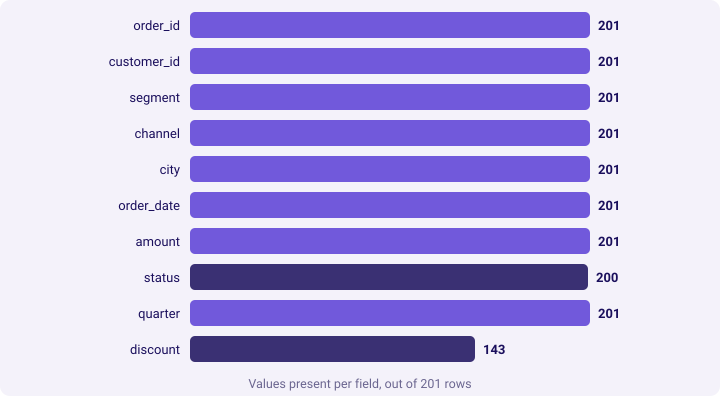

In [5]:
FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        values = [r.get(f, "") for r in rows]
        present = [v for v in values if v not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

prof = profile(raw)
kit.table(["field", "present", "convertible", "distinct"],
          [(f, p["present"], p["convertible"] if f in NUMERIC else "text", p["distinct"])
           for f, p in prof.items()],
          caption="The profile of the orders CSV: 201 rows")
kit.bars([(f, prof[f]["present"]) for f in FIELDS], lit=(7, 9),
         title="Values present per field, out of 201 rows")

**What happened.** The answer is b: `discount` is present on 143 of 201 rows, the gap Tuesday
met as an optional field. Three smaller signals matter more today. `order_id` is present on all
201 rows and distinct on only 186, so some order appears more than once. `amount` is present
on 201 rows and converts on 200. `status` is present on 200. None of those is a total yet; each
is a question the next rounds answer.

**Your turn.** A hurried analyst sums the amounts with `int()` straight away. Type these lines
into the empty cell below and run them. The loop stops with a `ValueError`; read the last line
aloud, write down the value it names, and say in one sentence what kind of value it is. You
have two minutes, because this is an error, not the lesson.

```python
total = 0
for r in raw:
    total += int(r["amount"])
```

In [6]:
kit.check("order_id repeats: fewer distinct ids than rows", prof["order_id"]["distinct"] < len(raw),
          f'{prof["order_id"]["distinct"]} distinct of {len(raw)}')
kit.check("one amount does not convert", prof["amount"]["present"] - prof["amount"]["convertible"] == 1)
kit.check("discount is optional on 58 rows", len(raw) - prof["discount"]["present"] == 58)

## 3. The trap: a conversion that makes the file look clean

**The plausible wrong answer.** The `ValueError` stops the pass, so the hurried fix is a helper
that turns anything unreadable into zero. The loop runs, the profile reports every amount
convertible, and Q1 comes out at the dashboard's figure. It reads like proof that the dashboard
was right and Finance is behind.

In [7]:
def to_int(value):
    try:
        return int(value)
    except ValueError:
        return 0                     # "so the loop does not crash"

coerced = [dict(r, amount=to_int(r["amount"])) for r in raw]
q1_coerced = sum(r["amount"] for r in coerced if r["quarter"] == "Q1")
failures_seen = sum(1 for r in coerced if not isinstance(r["amount"], int))
kit.stats([(f"{len(raw) - failures_seen} of {len(raw)}", "amounts convert", "the coerced profile"),
           (kit.rupees(q1_coerced), "Q1 revenue", "reads as the dashboard's 2.1 crore"),
           ("0", "failures reported", "nothing in any log")],
          caption="The hurried pass, as it would be reported")

**Why it is wrong.** A zero is a claim: it says Kalpa sold that order for nothing. Finance booked
it at a value, so the coerced file carries an order the books do not have, and the profile has
destroyed the one piece of evidence that something was wrong with it. The note to Anand would
say "every amount converts" and "Q1 is Rs 2,09,98,210", and his analyst, who ties out to the
rupee, would find a Rs 0 order in a file you called clean. The check that catches it asks a
business question of the result: can a Kalpa order be worth nothing?

In [8]:
zero_orders = [r for r in coerced if r["amount"] == 0]
smallest_real = min(v for v in (convert(r["amount"])[0] for r in raw) if v is not None)
kit.check("the coerced file holds an order at Rs 0", len(zero_orders) == 1, f"{len(zero_orders)} order")
kit.check("no convertible order in the export is below Rs 400", smallest_real >= 400,
          f"the smallest real amount is {kit.rupees(smallest_real)}")

**The fix.** Convert on purpose: `convert()` returns the number or the reason it failed, and every
failure goes to a rejects log with its file line, its field and its reason. The row is not
deleted and not zeroed; it is set aside where anybody can read why.

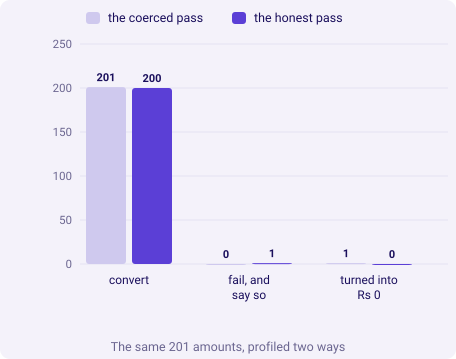

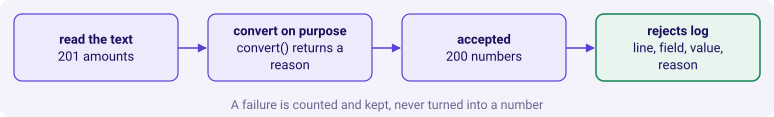

In [9]:
accepted, rejects = [], []
for r in raw:
    value, reason = convert(r["amount"])
    if value is None:
        rejects.append({"line": r["line"], "order_id": r["order_id"], "field": "amount",
                        "value": r["amount"], "reason": reason})
    else:
        accepted.append(dict(r, amount=value))

q1_accepted = sum(r["amount"] for r in accepted if r["quarter"] == "Q1")
kit.stats([(f"{len(accepted)} + {len(rejects)}", "accepted and logged", f"of {len(raw)} rows"),
           (kit.rupees(q1_accepted), "Q1, amounts that convert", "the same rupees, honestly labelled"),
           (str(len(zero_orders) - len([r for r in accepted if r["amount"] == 0])), "zero orders removed",
            "the Rs 0 order is gone")])
kit.columns(["convert", "fail, and say so", "turned into Rs 0"],
            [("the coerced pass", [len(raw), 0, 1]), ("the honest pass", [len(accepted), len(rejects), 0])],
            title="The same 201 amounts, profiled two ways")
kit.flow(["read the text\n201 amounts", "convert on purpose\nconvert() returns a reason",
          "accepted\n200 numbers", "rejects log\nline, field, value, reason"],
         lit=None, kinds=[None, None, None, "good"], title="A failure is counted and kept, never turned into a number")
kit.check("accepted plus rejected is every row", len(accepted) + len(rejects) == len(raw),
          f"{len(accepted)} + {len(rejects)} = {len(raw)}")
kit.check("no accepted order is worth Rs 0", all(r["amount"] > 0 for r in accepted))

**What changed.** The rupees did not move: Q1 over the amounts that convert is still
Rs 2,09,98,210. What moved is the claim. One order went from "sold for Rs 0" to "amount
unreadable, set aside on the line the log names", and the profile now reports one failure instead
of none. Whether that order is revenue is a question for round 2, because the log alone cannot
answer it.

**Your turn.** Print the rejects log in the empty cell below with `print(rejects)`, open the CSV
at the line it names, and read the whole row. Write one sentence on what a person would have to
know to give that order its real amount.

> **Kavya's review.** "A conversion that never fails is a conversion that lies. Show me the count
> of failures next to the count of successes, and the log that names each one."

## 4. The harder variant: the JSON feed and the vendor copy

The ERP sent two more files. The app's JSON feed should carry the same orders in another format,
and a vendor sent a short copy of the CSV. A second source is worth having only once you know
what it holds, so both get the same profile. The feed does not load: `json.load` stops with a
`JSONDecodeError`, and that message is worth two minutes.

**Your turn.** Type `json.load(open(DATA / "C2_W01_D03_orders_STUDENT.json"))` into the empty
cell below and run it. Read the last line: it names a line and a column. Open the file in the
editor at that line and describe what you see in one sentence.

**Predict before you run.** The feed cannot be parsed whole. The code below reads it one complete
record at a time and stops at the first record that is not complete. How should the feed be used
afterwards? a) in place of the CSV, because JSON is the app's own format; b) as a second witness,
compared field by field for the orders it holds; c) not at all, since a broken file proves nothing;
d) merged into the CSV, so nothing is lost.

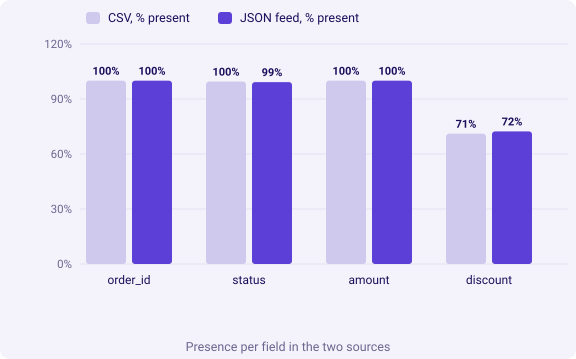

119 complete records recovered from the feed


In [10]:
text = (DATA / "C2_W01_D03_orders_STUDENT.json").read_text(encoding="utf-8")
decoder, feed, at = json.JSONDecoder(), [], text.index("{")
while True:
    try:
        record, end = decoder.raw_decode(text, at)
    except json.JSONDecodeError:
        break                         # the first record that is not complete ends the read
    feed.append(record)
    nxt = text.find("{", end)
    if nxt == -1:
        break
    at = nxt

feed_prof = profile(feed)
pct = lambda n, d: round(100 * n / d, 1)
kit.columns(["order_id", "status", "amount", "discount"],
            [("CSV, % present", [pct(prof[f]["present"], len(raw)) for f in ("order_id", "status", "amount", "discount")]),
             ("JSON feed, % present", [pct(feed_prof[f]["present"], len(feed)) for f in ("order_id", "status", "amount", "discount")])],
            fmt=lambda v: f"{v:.0f}%", title="Presence per field in the two sources")
print(len(feed), "complete records recovered from the feed")

**What happened.** The answer is b. The feed yields 119 complete records, all of them orders the
CSV also holds, so it covers part of the export and can confirm it field by field, but it can
never replace it. Missing looks different in each format: a CSV writes an absent value as an
empty string, while JSON leaves the key out, so `record["status"]` on a feed record can raise a
`KeyError` where the CSV quietly returned `""`. A profile that uses `.get(field, "")`, as this one
does, counts both the same way.

In [11]:
csv_by_id = {}
for r in accepted:
    csv_by_id.setdefault(r["order_id"], r)
in_csv = sum(1 for r in feed if r["order_id"] in csv_by_id)
same_amount = sum(1 for r in feed if r["order_id"] in csv_by_id
                  and convert(r.get("amount"))[0] == csv_by_id[r["order_id"]]["amount"])
kit.check("every feed record is an order the CSV holds", in_csv == len(feed), f"{in_csv} of {len(feed)}")
kit.check("the feed agrees with the CSV on nearly every amount", same_amount >= len(feed) - 1,
          f"{same_amount} of {len(feed)} agree")

The vendor copy is a short CSV, so it gets the same profile. A good profile shows a problem as a
count that does not fit, before anybody looks at a row.

**Predict before you run.** The vendor copy should hold 39 orders in two segments. If a text
line that is not an order had slipped in, which counts would move? a) only the row count;
b) the row count, and a field's convertible count, and a field's distinct count; c) nothing,
because DictReader skips it; d) only the distinct count of `order_id`.

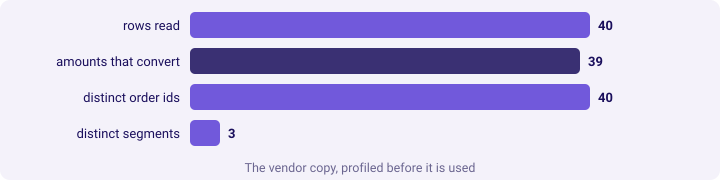

In [12]:
vendor = read_orders(DATA / "C2_W01_D03_vendor_STUDENT.csv")
vprof = profile(vendor)
kit.bars([("rows read", len(vendor)), ("amounts that convert", vprof["amount"]["convertible"]),
          ("distinct order ids", vprof["order_id"]["distinct"]), ("distinct segments", vprof["segment"]["distinct"])],
         title="The vendor copy, profiled before it is used", lit=(1,))

**What happened.** The answer is b: 40 rows read, 39 amounts convert, and the segment field
holds three distinct values where two were expected. Something that is not an order is being
read as one.

**Your turn.** In the empty cell below, print every vendor row whose amount does not convert, and
say what the row is and how it got there.

In [13]:
kit.check("the vendor copy reads one row more than its orders", len(vendor) == vprof["amount"]["convertible"] + 1)
kit.check("the vendor copy shows one segment too many", vprof["segment"]["distinct"] == 3)

### In the interview

**[F] Everything read from a CSV is a string; what breaks and where do you convert?** "Arithmetic,
comparison and sorting all break or, worse, silently do the wrong thing. Adding text to a number
raises a TypeError; comparing `'900'` with `'1200'` sorts by character and puts 900 last; `max` on
text amounts returns the one that starts with the highest digit. I convert once, at the boundary,
in one function that returns the value or the reason it failed, and I count and log the failures.
I never convert inside the analysis, and I never turn a failure into a default without writing
that decision down, because a zero or a blank is a claim about the business."

**[S] How do you handle missing data?** "First I measure it per field: present, convertible,
distinct. Then I ask what the absence means, because an optional discount that is absent means
no discount, while a missing status means we do not know the order's fate. Then one of three
decisions, each written down with its reason: drop the record, fill a stated default, or keep
it and flag it. For money I almost never fill, since the books either have a value or they do
not."

### Depth: LBYL against EAFP

Python offers two styles for a conversion. Look before you leap checks first, as
`value.isdigit()` does, and misses cases such as `"-2400"`, which is a valid integer that
`isdigit` rejects. Easier to ask forgiveness tries the conversion and handles the exception, as
`convert()` does, which is why this pack converts that way: the rule for what counts as a valid
amount lives in one place, `int()`, and every refusal comes back with a reason. Real Python's
article on the two styles (verified 03 Sep 2026, https://realpython.com/python-lbyl-vs-eafp/)
walks both.

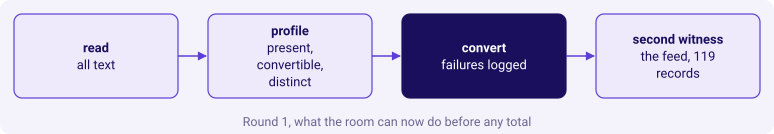

What round 1 established,The number
Rows the ERP sent in the orders CSV,201
Distinct order ids among them,186
"Amounts that convert, and failures logged",200 and 1
Q1 over the amounts that convert,"Rs 2,09,98,210"
Complete records in the JSON feed,119


Next: round 2 asks why 201 rows hold only 186 orders, and what that does to Q1.


In [14]:
kit.flow(["read\nall text", "profile\npresent, convertible, distinct", "convert\nfailures logged",
          "second witness\nthe feed, 119 records"], lit=2,
         title="Round 1, what the room can now do before any total")
kit.table(["What round 1 established", "The number"],
          [("Rows the ERP sent in the orders CSV", "201"),
           ("Distinct order ids among them", "186"),
           ("Amounts that convert, and failures logged", "200 and 1"),
           ("Q1 over the amounts that convert", kit.rupees(q1_accepted)),
           ("Complete records in the JSON feed", str(len(feed)))],
          caption="The profile, before anyone reconciles")
kit.check_summary()
print("Next: round 2 asks why 201 rows hold only 186 orders, and what that does to Q1.")